In [45]:
import os, sys, re
import pandas as pd
#import pandas_datareader.data as pdr
import numpy as np
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


# библиотека для расчетов метрик
from sklearn import metrics

# библиотека модели линейной регрессии
from sklearn import linear_model

# библиотека модели ансамблей
from sklearn import ensemble

# библиотека для разделения датасета
from sklearn import model_selection

# для обработки timestamp в формате utc
from datetime import datetime

# выводить все результаты вычислений в ячейках Code
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# скрытие сообщений об ошибках при обработке ответов
import warnings
# игнорируем предупреждения
warnings.filterwarnings('ignore')

# подключить сборщик "мусора"
import gc

# from pandas_datareader import DataReader
# import pandas_datareader.data as pdr

# библиотека моделей ARIMA
from statsmodels.tsa.arima import model

# библиотека построения коррелограмм
from statsmodels.graphics import tsaplots

# тесты (тест Дики-Фуллера)
from statsmodels.tsa import stattools

# библиотека импорта котировок с агрегатора Yahoo Finance
import yfinance as yf

# библиотека экспорта модели в бинарном состоянии
import pickle

# библиотека Prophet
from prophet import Prophet

# библиотека catboost
import catboost as cb
from catboost import utils



In [30]:
# КОНСТАНТЫ
SRC_SUBFOLDER = './.'

# формируем относительный системный путь для импорта файлов с функциями
# если SRC_SUBFOLDER = './.' + './', получим относительный путь './../'
sys.path.append(os.path.relpath(SRC_SUBFOLDER + './'))

# импортируем внешние константы
from src.constants import *

# импортируем собственные функции
from src.funcs_1 import *
from src.funcs_2 import *

# 1. Загрузка данных

Загружаем котировки 4-х российских компаний https://finance.yahoo.com/lookup/ за 5 лет за промежуток 2017 - 2022 года.

Соединяем все данные в один массив

In [4]:
# будем анализировать фантастическую четвёрку
tick_list = ['GAZP.ME', 'SBER.ME', 'LKOH.ME', 'TATN.ME']

# исходный пустой датафрейм
df = pd.DataFrame()

# загружаем данные, объединяем котировки в один датафрейм
for tick in tick_list:
    df = pd.concat([df, yf.download(tick, start=datetime(2017, 1, 1), end=datetime(2022, 1, 1), period=str(5) + 'y', interval='1d')['Close']], axis=1)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 1.1 Предобработка данных

In [5]:
# переименовываем признаки, т.к. они имеют одинаковое имя интересующего признака - 'Close'
df.columns = ['Close' + str(col[0]) if col[1] == 'Close' else col[1] for col in enumerate(df.columns)]

# переименовываем признаки, в соответствии с загруженными данными
df.rename(columns=dict(zip(df.columns.to_list(), tick_list)), inplace=True)

# выводим результат
df

,GAZP.ME,SBER.ME,LKOH.ME,TATN.ME
Date,,,,
2017-01-03,114.360970,132.078598,2443.931641,289.387482
2017-01-04,114.172424,129.020828,2378.646484,290.167419
2017-01-05,111.677811,126.051033,2309.943115,275.769653
2017-01-06,111.750320,125.163788,2300.372070,275.249603
2017-01-09,111.967873,123.447899,2313.702637,276.777130
...,...,...,...,...
2021-12-24,338.250000,293.619995,6318.000000,471.777039
2021-12-27,342.779999,295.000000,6370.000000,481.285126
2021-12-28,345.000000,295.529999,6479.000000,485.990143


## 1.2 Формирование Time Series

In [6]:
# преобразуем столбец индексных меток к временнОму типу
df.index = pd.DatetimeIndex(df.index.values)

# выводим результат
df
df.index

,GAZP.ME,SBER.ME,LKOH.ME,TATN.ME
2017-01-03,114.360970,132.078598,2443.931641,289.387482
2017-01-04,114.172424,129.020828,2378.646484,290.167419
2017-01-05,111.677811,126.051033,2309.943115,275.769653
2017-01-06,111.750320,125.163788,2300.372070,275.249603
2017-01-09,111.967873,123.447899,2313.702637,276.777130
...,...,...,...,...
2021-12-24,338.250000,293.619995,6318.000000,471.777039
2021-12-27,342.779999,295.000000,6370.000000,481.285126
2021-12-28,345.000000,295.529999,6479.000000,485.990143
2021-12-29,339.489990,293.000000,6488.500000,484.421844


DatetimeIndex(['2017-01-03', '2017-01-04', '2017-01-05', '2017-01-06',
               '2017-01-09', '2017-01-10', '2017-01-11', '2017-01-12',
               '2017-01-13', '2017-01-16',
               ...
               '2021-12-17', '2021-12-20', '2021-12-21', '2021-12-22',
               '2021-12-23', '2021-12-24', '2021-12-27', '2021-12-28',
               '2021-12-29', '2021-12-30'],
              dtype='datetime64[ns]', length=1258, freq=None)

## 1.3 Интерполяция *NaN*-значений

В связи с тем, что биржевые котировки акций торгуются только в рабочие дни, т.н. *business days*, то данные по субботам и воскресеньям будут отсутствовать, т.е. приведёт при **upsampling**'е к появлению пустых (*NaN*) значений, заполним их методом **[ffill()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html?highlight=ffill#pandas.DataFrame.ffill)**, заполнять будем первым непустым значением с помощью **[first()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.first.html?highlight=first#pandas.DataFrame.first)**:

In [7]:
# выполняем upsampling до '1D' и заполняем NaN-значения со сдвигом вперёд
df = df.resample('D').first().ffill()

# выводим результат
df
df.index

,GAZP.ME,SBER.ME,LKOH.ME,TATN.ME
2017-01-03,114.360970,132.078598,2443.931641,289.387482
2017-01-04,114.172424,129.020828,2378.646484,290.167419
2017-01-05,111.677811,126.051033,2309.943115,275.769653
2017-01-06,111.750320,125.163788,2300.372070,275.249603
2017-01-07,111.750320,125.163788,2300.372070,275.249603
...,...,...,...,...
2021-12-26,338.250000,293.619995,6318.000000,471.777039
2021-12-27,342.779999,295.000000,6370.000000,481.285126
2021-12-28,345.000000,295.529999,6479.000000,485.990143
2021-12-29,339.489990,293.000000,6488.500000,484.421844


DatetimeIndex(['2017-01-03', '2017-01-04', '2017-01-05', '2017-01-06',
               '2017-01-07', '2017-01-08', '2017-01-09', '2017-01-10',
               '2017-01-11', '2017-01-12',
               ...
               '2021-12-21', '2021-12-22', '2021-12-23', '2021-12-24',
               '2021-12-25', '2021-12-26', '2021-12-27', '2021-12-28',
               '2021-12-29', '2021-12-30'],
              dtype='datetime64[ns]', length=1823, freq='D')

In [8]:
# проверяем пустые значения
df.isna().sum()

GAZP.ME    0
SBER.ME    0
LKOH.ME    0
TATN.ME    0
dtype: int64

# 2. EDA

## 2.1 Общий анализ

Посмотрим общую картинку, что из себя представляют данные

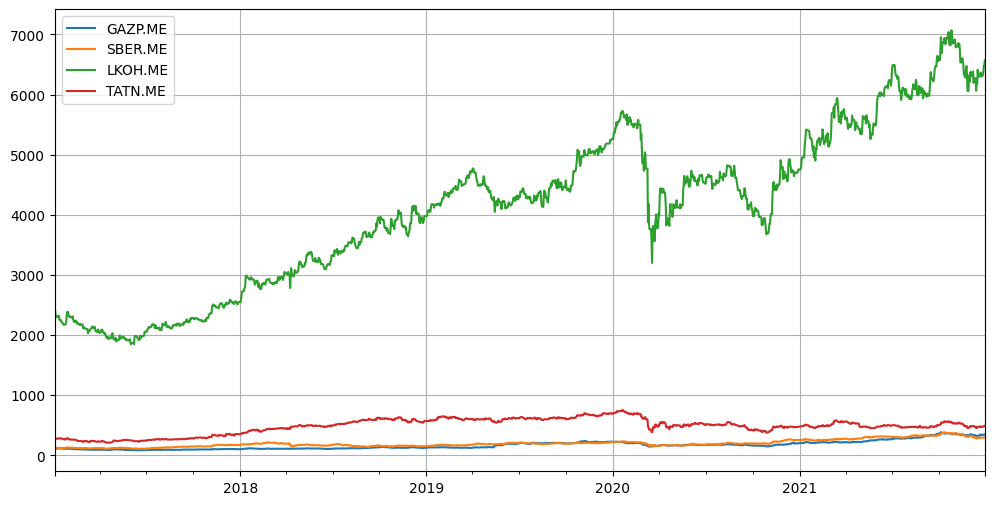

In [10]:
plt.rcParams['figure.figsize'] = 12, 6
df.plot()
plt.grid();

На изображении представлен график, который отображает изменения цен акций четырех компаний с 2017 года до 2021 года:
 1. GAZP.ME — акционерная компания, которая на графике изображена синим цветом. Ее цена акций значительно увеличивается в период с 2018 по 2021 год, что отражает заметный рост.
 2. SBER.ME — акции Сбербанка, представленные оранжевым цветом. В течение всего периода на графике видно небольшое увеличение цены акций, но в сравнении с другими компаниями рост явно не так значительный.
 3. LKO.ME — акции компании ЛУКОЙЛ, изображены зеленым цветом. Линия на графике показывает устойчивый и значительный рост акций, особенно начиная с 2020 года, что указывает на динамичное улучшение стоимости.
 4. TATN.ME — акции компании Татнефть, представленные красным цветом. Стоимость акций в этом случае остается на более низком уровне по сравнению с другими компаниями, и рост также меньше, чем у LKO.ME и GAZP.ME.

Основные наблюдения:

 * LKO.ME показывает наиболее заметный рост среди всех компаний.
 * GAZP.ME также демонстрирует стабильный рост, но он менее выражен, чем у ЛУКОЙЛа.
 * SBER.ME и TATN.ME имеют более скромные изменения цен акций.

График позволяет сделать вывод, что в данном периоде компании с более высокими ценами акций, как правило, имеют более стабильный рост, но не все акции показывают одинаковую динамику.

## 2.2 Корреляция данных

Посмотрим на парные графики корреляций:

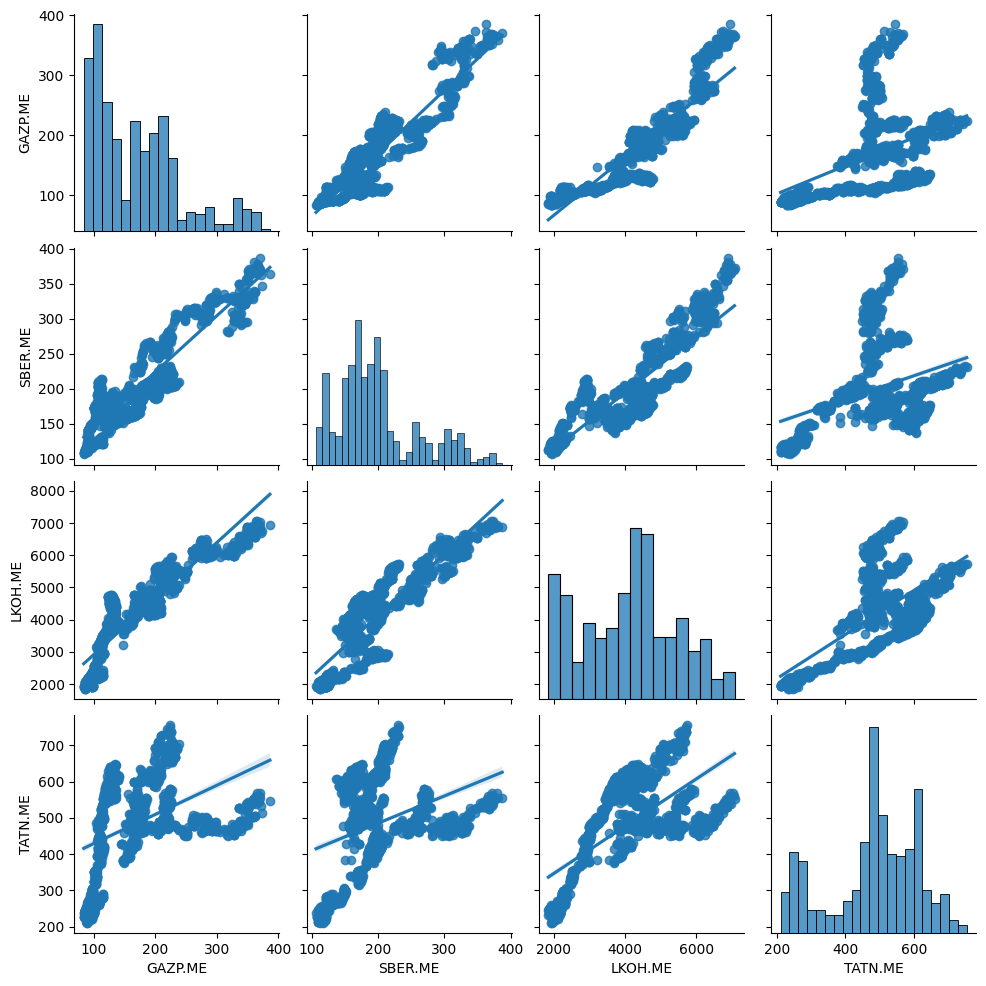

In [9]:
sns.pairplot(df, kind='reg');

1. Диагональные графики (гистограммы):
 * На диагонали отображены гистограммы для каждой компании. Эти графики показывают распределение цен акций внутри каждой компании.
 * Например:
 * GAZP.ME (синий цвет) имеет более широкое распределение с частыми пиками в диапазоне 100-300, что указывает на относительно равномерное распределение цен.
 * SBER.ME (оранжевый цвет) также имеет распределение, но с меньшими колебаниями в ценах, с пиками, близкими к 200.
 * LKO.ME (зеленый цвет) показывает гораздо более высокие значения и более выраженное распределение цен.
 * TATN.ME (красный цвет) также имеет большую вариативность, с несколькими пиками на гистограмме.
 2. Вне диагонали (графики рассеяния):
 * Графики рассеяния отображают взаимосвязь между ценами акций различных компаний.
 * GAZP.ME vs SBER.ME: График показывает слабую положительную корреляцию между ценами акций двух компаний. Есть тренд на рост, но с небольшими колебаниями.
 * GAZP.ME vs LKO.ME: Здесь наблюдается более выраженная положительная корреляция. Обе компании показывают схожие тренды роста.
 * GAZP.ME vs TATN.ME: Несмотря на рост цен, данные на этом графике распределяются менее равномерно, что указывает на меньшую корреляцию.
 * SBER.ME vs LKO.ME: Линия тренда показана, что обе компании имеют позитивную корреляцию в росте цен, но с разными уровнями роста.
 * SBER.ME vs TATN.ME: Видно, что TATN.ME и SBER.ME также имеют положительную корреляцию, но линия тренда не так четко выражена, что может указывать на менее сильную связь между ними.
 * LKO.ME vs TATN.ME: Взаимосвязь между этими компаниями относительно слабая, хотя оба графика показывают рост акций.
 3. Тренды:
 * На некоторых графиках видны линии тренда (показаны прямыми линиями), что подтверждает общую тенденцию к росту цен акций большинства компаний, особенно для GAZP.ME и LKO.ME.
 * Для SBER.ME и TATN.ME линия тренда менее выражена.

Общие наблюдения:

 * LKO.ME демонстрирует значительные колебания в ценах акций и имеет наибольший рост среди всех компаний.
 * GAZP.ME и LKO.ME показывают схожие тенденции роста в цене акций.
 * SBER.ME и TATN.ME менее волатильны, однако на графиках видно, что для TATN.ME изменения цен в определенные периоды были более выражены.
 * Все компании, за исключением TATN.ME, демонстрируют более выраженную положительную корреляцию в трендах роста цен.

Рассмотрим тепловую карту

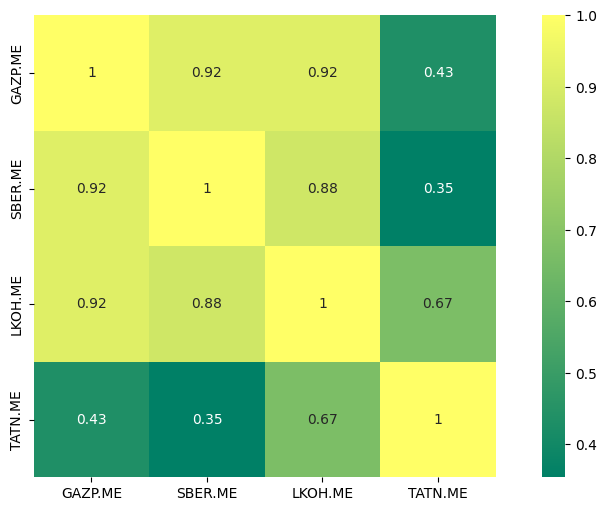

In [10]:
sns.heatmap(
    df.corr(), 
    annot=True, 
    square=True, 
    cmap='summer'
);

1. Ось X и ось Y:
 * Ось X и ось Y отображают акции компаний, на которых проводился расчет корреляции. Компании следующие:
 * GAZP.ME
 * SBER.ME
 * LKO.ME
 * TATN.ME
 2. Корреляция:
 * Каждый квадрат в матрице показывает корреляцию между двумя компаниями. Чем ближе значение к 1, тем сильнее положительная линейная зависимость между двумя акциями.
 * Если значение корреляции близко к 0, это указывает на слабую или отсутствующую зависимость.
 3. Корреляции:
 * GAZP.ME vs SBER.ME: Корреляция 0.92, что указывает на сильную положительную зависимость.
 * GAZP.ME vs LKO.ME: Также сильная положительная корреляция 0.92.
 * GAZP.ME vs TATN.ME: Здесь корреляция значительно ниже — 0.43, что указывает на более слабую связь.
 * SBER.ME vs LKO.ME: Корреляция 0.88, что указывает на высокую положительную связь.
 * SBER.ME vs TATN.ME: Корреляция 0.35, что свидетельствует о более слабой положительной связи.
 * LKO.ME vs TATN.ME: Корреляция 0.67, указывающая на умеренно сильную связь.
 4. Цветовая шкала:
 * Цвета на графике варьируются от желтого (низкая корреляция, около 0) до зеленого (высокая корреляция, около 1). Чем более зеленый квадрат, тем сильнее корреляция.

Основные выводы:

 * GAZP.ME и LKO.ME имеют очень сильную положительную корреляцию (0.92), что означает, что их цены движутся в схожем направлении.
 * TATN.ME имеет слабую корреляцию с другими компаниями, особенно с GAZP.ME и SBER.ME, что указывает на низкую зависимость между этими акциями.
 * LKO.ME и SBER.ME имеют высокую корреляцию, но не такую сильную, как у GAZP.ME и LKO.ME.

Этот график полезен для анализа взаимосвязи цен акций, чтобы определить, какие компании имеют схожие тенденции в изменении своих рыночных цен.

### **Выводы:**

* Компании зависят друг от друга и эффективность ведения совместных договоренностей приводит к росту обеих и каждого.

## 2.3 Исследование котировок компании

Выберем одну котировку для наглядного исследования, остальные котировки будут подвергнуты идентичным шагам построения моделей, повторять и дублировать исследования в виде графиков и вычислений не буду, в целях краткости и наглядности, данные по остальным котировкам будут сведены в итоговую сравнительную таблицу и представлены в разделе 4 - "Результаты, выводы".

In [9]:
# выбираем котировку Лукойл
data = pd.DataFrame(df[df.columns[2]])

# выводим результат
data.head(1)

,LKOH.ME
2017-01-03,2443.931641


### 2.3.1 Оценка наличия тренда и сезонности ряда

Посмотрим на тренд и сезонность

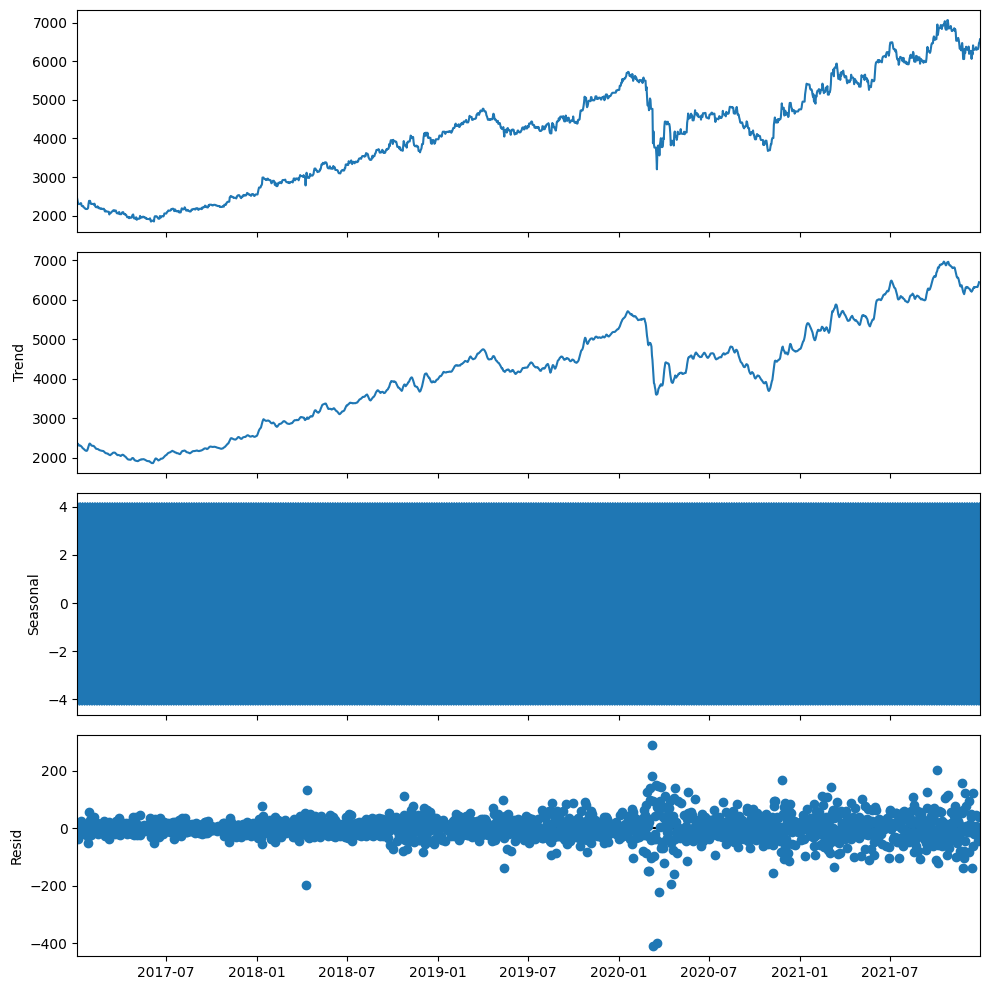

In [10]:
# декомпозиция 
from statsmodels.tsa import seasonal

# библиотека построения коррелограмм
from statsmodels.graphics import tsaplots

plt.rcParams['figure.figsize'] = 10, 10

# производим декомпозицию временного ряда
decomposition = seasonal.seasonal_decompose(data, period=5)
decomposition.plot();

Графики показывают:
 1. Исходный временной ряд (верхний график):
 * Этот график представляет собой исходные данные (например, изменения цен акций или другого показателя). Мы видим трендовый рост с некоторыми скачками, что может быть связано с событиями или изменениями на рынке.
 2. Тренд (средний график):
 * Тренд показывает долгосрочное направление временного ряда без сезонных колебаний и случайных изменений. Это основная линия роста, которая представляет собой общую тенденцию изменения данных во времени (в данном случае заметен устойчивый рост с течением времени).
 3. Сезонность (нижний график, который почти плоский):
 * Сезонность показывает регулярные циклические колебания данных, которые происходят на основе времени года, месяцев или других регулярных периодов. На этом графике видно, что сезонных колебаний в данных почти нет, что может свидетельствовать о стабильности данных в разные сезоны.
 4. Остатки (Residuals) (самый нижний график):
 * Остатки — это разница между наблюдаемыми значениями и значениями, предсказанными на основе тренда и сезонности. Этот график показывает случайные колебания, которые не могут быть объяснены трендом или сезонными изменениями. Здесь можно увидеть, что остатки относительно случайны, без явных трендов, что подтверждает адекватность модели для анализа.

Общее описание:

Этот разложенный анализ помогает понять, какие компоненты влияют на временной ряд, разделяя данные на:
 * Тренд — основное направление.
 * Сезонность — цикличность, повторяющиеся паттерны.
 * Остатки — случайные флуктуации, которые не могут быть объяснены трендом или сезонностью.

Выводы:

 * Данные имеют ярко выраженный трендовый рост.
 * Сезонность невозможно оценить, так как график сезонных колебаний почти плоский.

Посмотрим на график сезонности детальней, выберем последние 50 значений и мы видим явную сезонность с "окном" в 7 дней

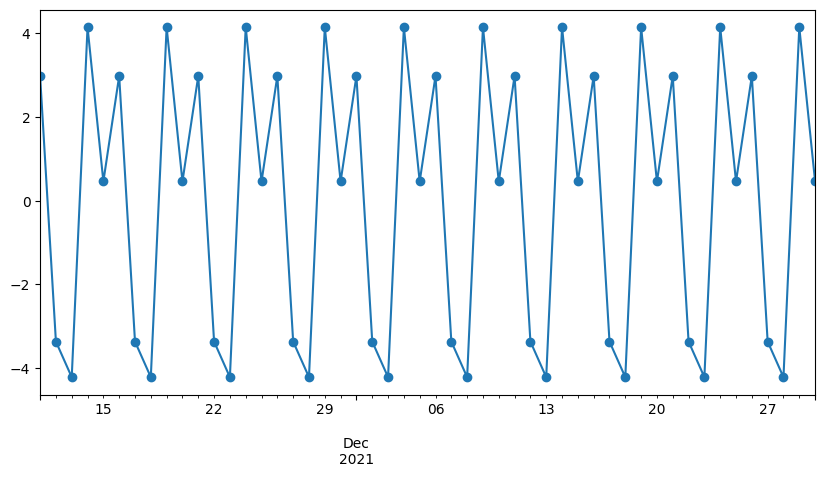

In [11]:
plt.rcParams['figure.figsize'] = 10, 5
decomposition.seasonal[-50:].plot(marker='o');

### **Выводы:**

Предварительная оценка, при анализе ряда наблюдается:

* тренд;
* наличие сезонности;
* присутствие шума, остатки сосредоточены близко 0.

---

### 2.3.2 Разбиение данных

Разобъём данные на тренировочную и тестовые выборки - окна в 90 дней (5 % на тестовые данные) должно хватить на валидацию при имеющихся более 1500 записей:

In [12]:
# разбиение выборки
train_df, test_df = split_data(data, SPLIT_SIZE)

# выводим результат
print(f'Размерность тренировочной выборки: {train_df.shape}')
print(f'Размерность тестовой выборки: {test_df.shape}')

Размерность тренировочной выборки: (1732, 1)
Размерность тестовой выборки: (91, 1)


In [13]:
# выводим результат
test_df

,LKOH.ME
2021-10-01,6574.676270
2021-10-02,6574.676270
2021-10-03,6574.676270
2021-10-04,6760.166016
2021-10-05,6954.668945
...,...
2021-12-26,6318.000000
2021-12-27,6370.000000
2021-12-28,6479.000000
2021-12-29,6488.500000


### 2.3.3 Оценка стационарности ряда, выбор модели

Построим коррелограммы, чтобы оценить корреляцию

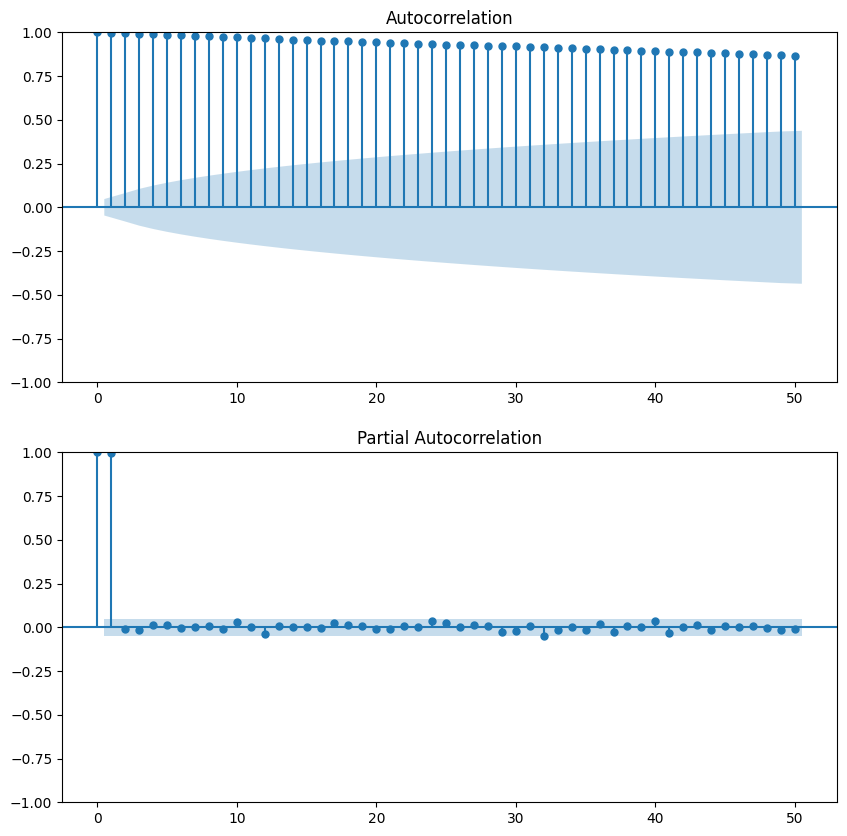

In [20]:
get_correlograms(train_df, 50)

Оценим стационарность ряда с помощью функции `get_adfuller_test` (тест Дики-Фуллера):

In [21]:
# проверяем ряд на стационарность
get_adfuller_test(train_df, 2)

ADF Statistic: -0.3834633671467024
p-value: 0.9128234054380132
Critical Values: {'1%': np.float64(-3.434133375964546), '5%': np.float64(-2.8632111492477503), '10%': np.float64(-2.5676596723058402)}
При пороге '5%' есть единичные корни, ряд НЕ стационарен


In [22]:
# проверяем ряд на стационарность, интегрированный ряд 1-го порядка
get_adfuller_test(train_df.diff().dropna(), 2)

ADF Statistic: -42.42569892357745
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4341355661448856), '5%': np.float64(-2.8632121160561694), '10%': np.float64(-2.5676601871094924)}
При пороге '5%' единичных корней нет, ряд СТАЦИОНАРЕН


Интегрированный ряд 1-го порядка ряд стал стационарным, принимаем $d = 1$, т.к. ряд нестационарный и не требуется учитывать экзогенные переменные, то можно применить модель *SARIMA*, в связи с наличием сезонности.

Посмотрим на коррелограммы:

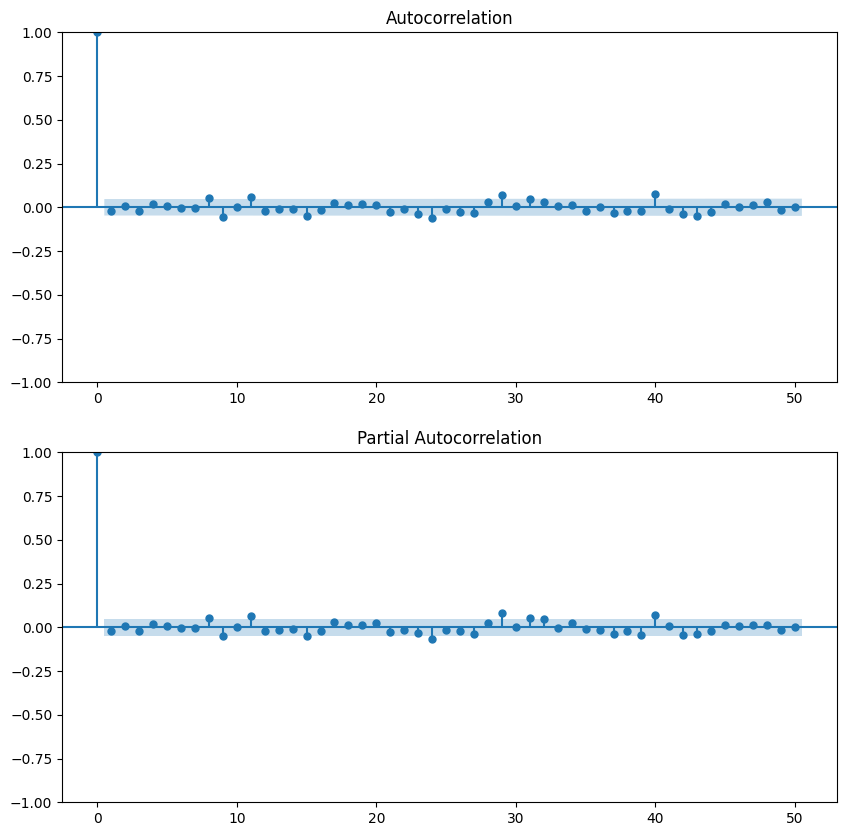

In [23]:
get_correlograms(train_df.diff().dropna(), 50)

На основании графиков автокорреляции и частичной автокорреляции выбираем параметры для модели:

* $p = 1$,
* $q = 1$.

### **Выводы:**

Предварительные параметры для SARIMA-модели:

* $p = 1$,
* $d = 1$, 
* $q = 1$.



---

# 3. Моделирование

## 3.1 Baseline. Модель SMA (простое скользящее среднее)

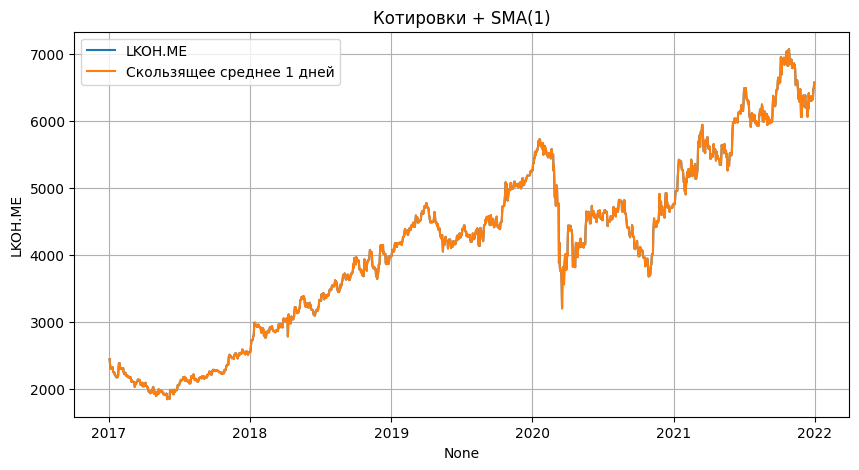

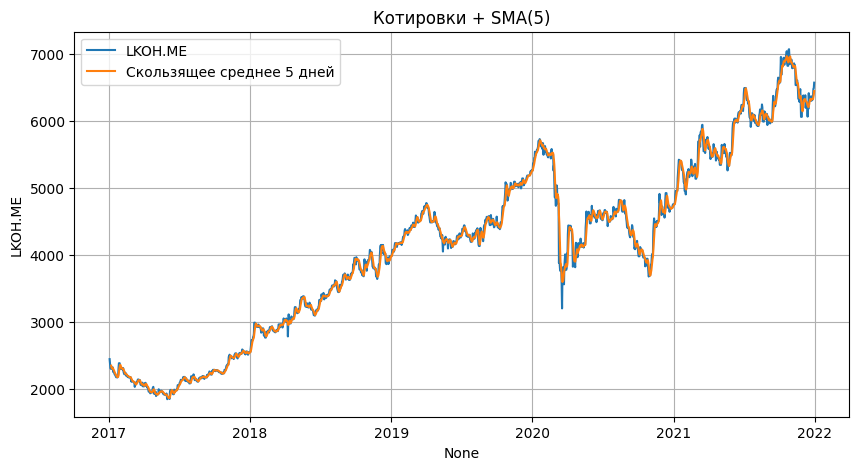

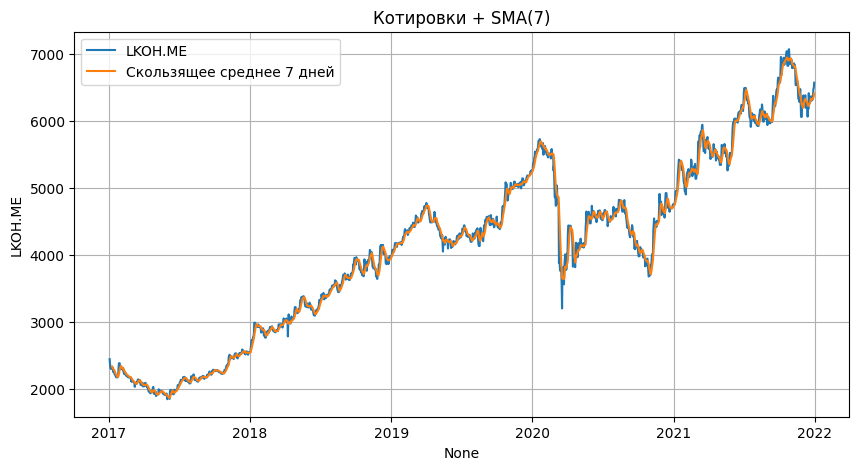

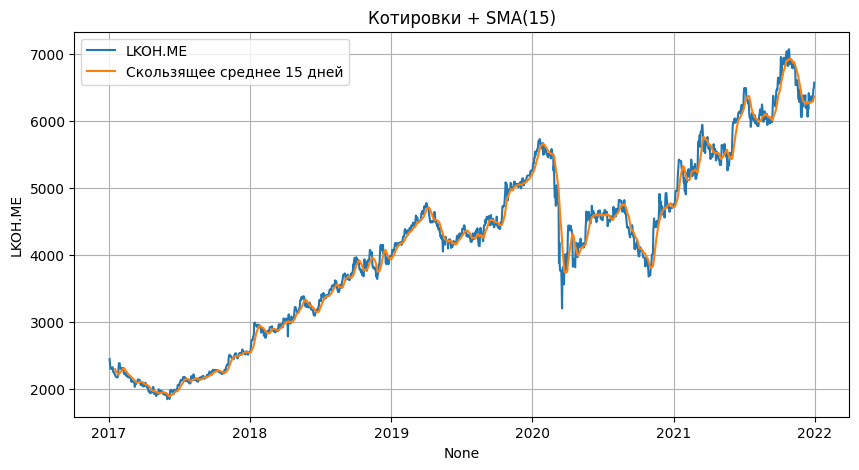

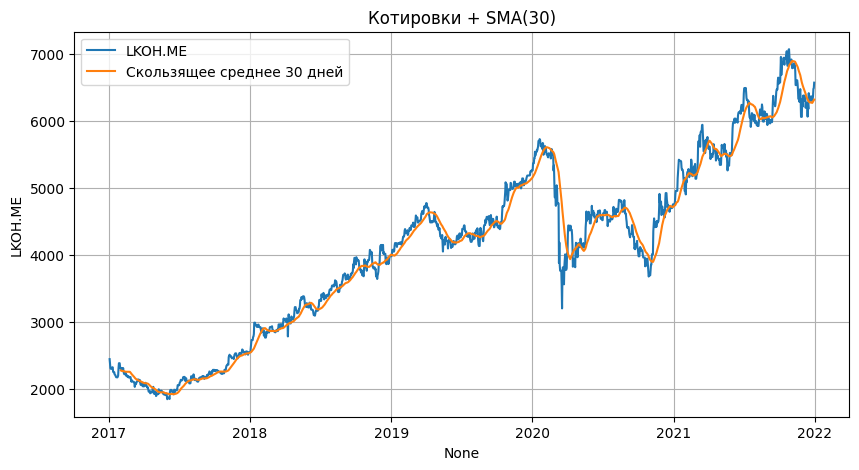

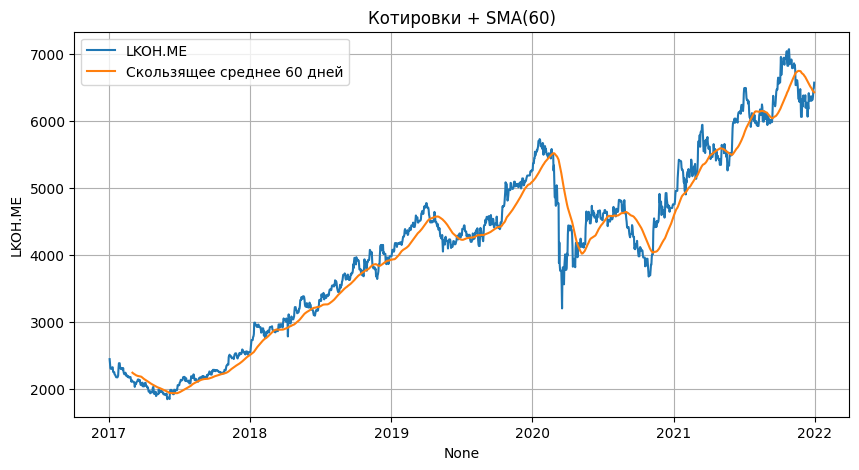

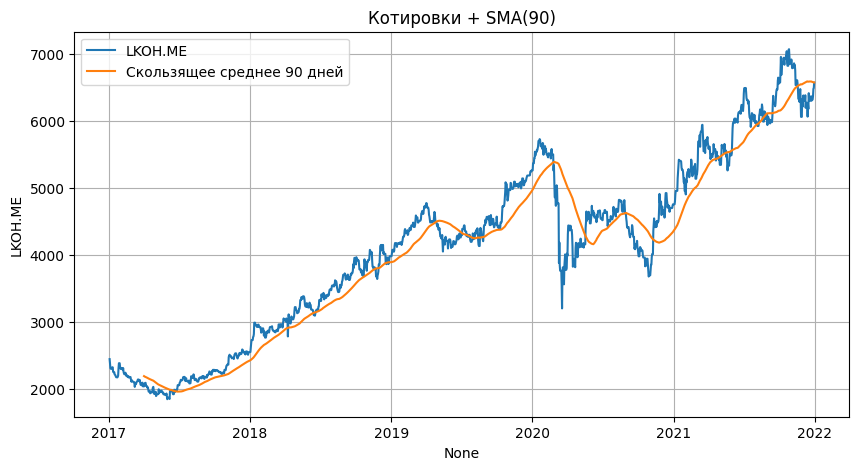

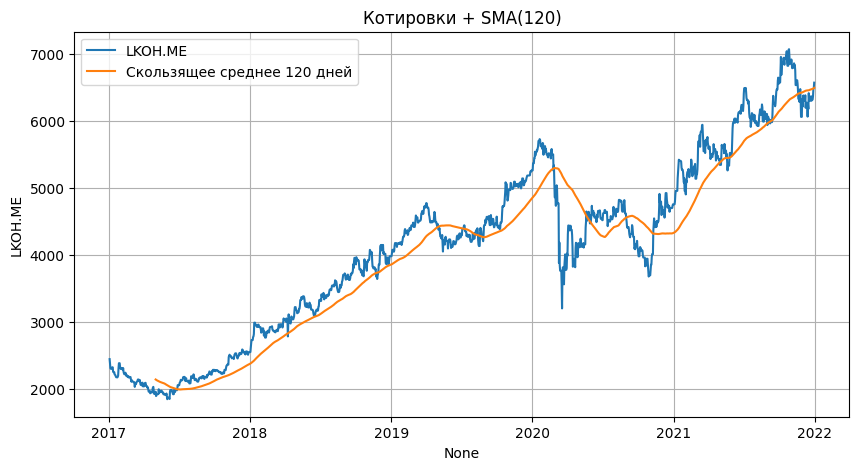

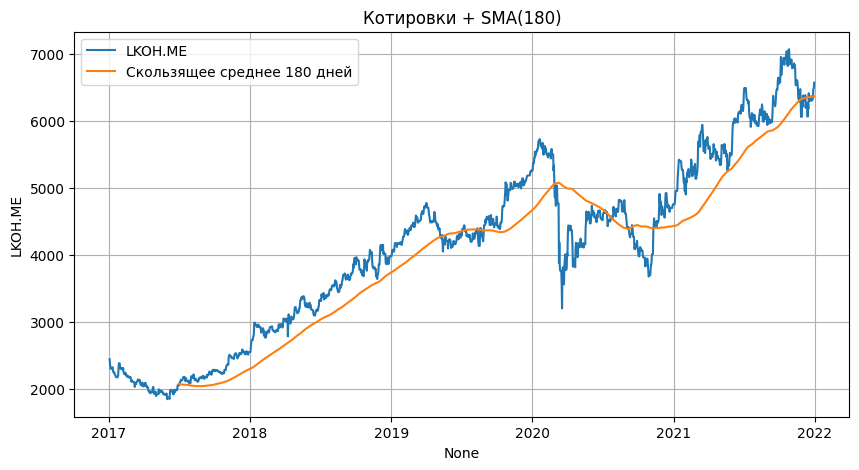

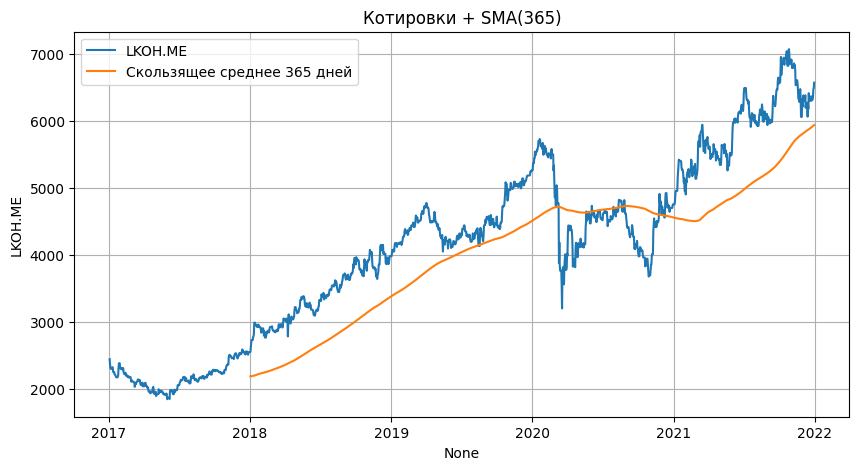

In [14]:
# строим SMA с окнами в диапазоне от 1 до 365, включительно
for i in [1, 5, 7, 15, 30, 60, 90, 120, 180, 365]:
    # задаём полотно
    fig, ax_line = plt.subplots(figsize=(10, 5))
    
    # строим график основных данных
    ax_line = sns.lineplot(x=data.index, y=data[data.columns[0]], label=data.columns[0])

    # строим график SMA
    ma = data.rolling(i).mean()
    ax_line = sns.lineplot(x=ma.index, y=ma[data.columns[0]], label='Скользящее среднее '  + str(i) + ' дней')
    
    # формируем заголовок и сетку
    ax_line.grid()
    _ = plt.title('Котировки + SMA(' + str(i) + ')')

Скользящее среднее помогает избавить временной ряд от выбросов и лишнего шума, это упрощает визуальный анализ, но вместе с тем, с увеличением "окна", оборотная сторона медали - приходится платить потерей данных, причем, существенно. Модель SМА с окном в 60 дней и более очень сильно сгладила график, потеряна часть данных - скачки и пики просто "срезаны", график идёт "наперерез", "съедая и срезая углы", SМА с окном в 30 дней сгладила данные максимально аккуратно, сохранив пики и переходы.

В связи с тем, что тестовая выборка составляет порядка 90 записей, то для объективности оценки, принимаем скользящее среднее с окном в 90 дней:

In [16]:
# метрики SMA(90)
get_metrics(test_df, data[data.columns[0]].rolling(90).mean().iloc[len(train_df):])

MAPE: 5.68 %
MSE: 1.85144e+05 $^2
RMSE: 4.30283e+02 $
MAPE: 5.68 %
MSE: 1.85e+05 $^2
RMSE: 4.30e+02 $


## 3.2 Подбор гиперпараметров для SARIMA с помощью `pmdarima`

Попробуем подобрать оптимальные гиперпараметры для модели *ARIMA*:

* Параметр $p$: в диапазоне [1-13],
* Параметр $q$: в диапазоне [1-13],
* Задаем наличие сезонности: **m = 5** и **seasonal=True**,
* Фиксируем **random_state** и **n_jobs**, чтобы результаты были без учёта стохастического влияния и с максимальной производительностью, делаем вывод расчётов **trace** и подавляем ошибки **error_action='ignore'**, **suppress_warnings=True**,
* Чтобы сократить время расчётов убираем расчёты с интерсептом: **with_intercept=False**.

In [15]:
# библиотека подбора параметров 

import pmdarima as pm

# ищем лучшие гиперпараметры для модели интерполированными значениями
AUTO_ARIMA = pm.auto_arima(
    train_df, 
    start_p=1, d=1, start_q=1,
    max_p=10, max_d=10, max_q=10, 
    start_P=1, D=1, start_Q=1, 
    max_P=10, max_D=1, max_Q=10, 
    test='adf',
    m=5, seasonal=True, 
    trace=True,
    error_action='ignore', 
    suppress_warnings=True, 
    n_jobs=-1, 
    random_state=42, 
    with_intercept=False
)

# выводим результат
AUTO_ARIMA.summary()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[5]             : AIC=inf, Time=0.87 sec
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=20340.258, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=19850.164, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=inf, Time=0.44 sec
 ARIMA(1,1,0)(0,1,0)[5]             : AIC=20340.873, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[5]             : AIC=19692.433, Time=0.25 sec
 ARIMA(1,1,0)(3,1,0)[5]             : AIC=19557.037, Time=0.41 sec
 ARIMA(1,1,0)(4,1,0)[5]             : AIC=19491.316, Time=0.67 sec
 ARIMA(1,1,0)(5,1,0)[5]             : AIC=19437.589, Time=0.97 sec
 ARIMA(1,1,0)(6,1,0)[5]             : AIC=19411.108, Time=1.70 sec
 ARIMA(1,1,0)(7,1,0)[5]             : AIC=19345.190, Time=2.11 sec
 ARIMA(1,1,0)(8,1,0)[5]             : AIC=19323.643, Time=3.18 sec
 ARIMA(1,1,0)(9,1,0)[5]             : AIC=19312.311, Time=3.86 sec
 ARIMA(1,1,0)(10,1,0)[5]             : AIC=19299.996, Time=11.26 sec
 ARIMA(1,1,0)(10,1,1)[5]     

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                 1732
Model:             SARIMAX(0, 1, 0)x(10, 1, 0, 5)   Log Likelihood               -9638.246
Date:                            Thu, 20 Mar 2025   AIC                          19298.493
Time:                                    15:44:11   BIC                          19358.482
Sample:                                01-03-2017   HQIC                         19320.684
                                     - 09-30-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L5       -0.9111      0.016    -56.249      0.000      -0.943      -0.879
ar.S.L10      -0.8272      0.023    -36.694      0.000      -0.871      -0.783
ar.S.L15      -0.7921      0.024    -32.583      0.000      -0.840      -0.744
ar.S.L20      -0.6869      0.026    -26.169      0.000      -0.738      -0.635
ar.S.L25      -0.6048      0.030    -20.405      0.000      -0.663      -0.547
ar.S.L30      -0.5089      0.032    -15.676      0.000      -0.573      -0.445
ar.S.L35      -0.4410      0.031    -14.382      0.000      -0.501      -0.381
ar.S.L40      -0.2724      0.030     -9.209      0.000      -0.330      -0.214
ar.S.L45      -0.1723      0.023     -7.371      0.000      -0.218      -0.127
ar.S.L50      -0.0926      0.018     -5.015      0.000      -0.129      -0.056
sigma2      4127.9512     46.594     88.594      0.000    4036.629    4219.274
===================================================================================
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):             46056.13
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               9.10   Skew:                            -0.94
Prob(H) (two-sided):                  0.00   Kurtosis:                        28.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Оценим визуально модель SARIMA полученную на гиперпараметрах

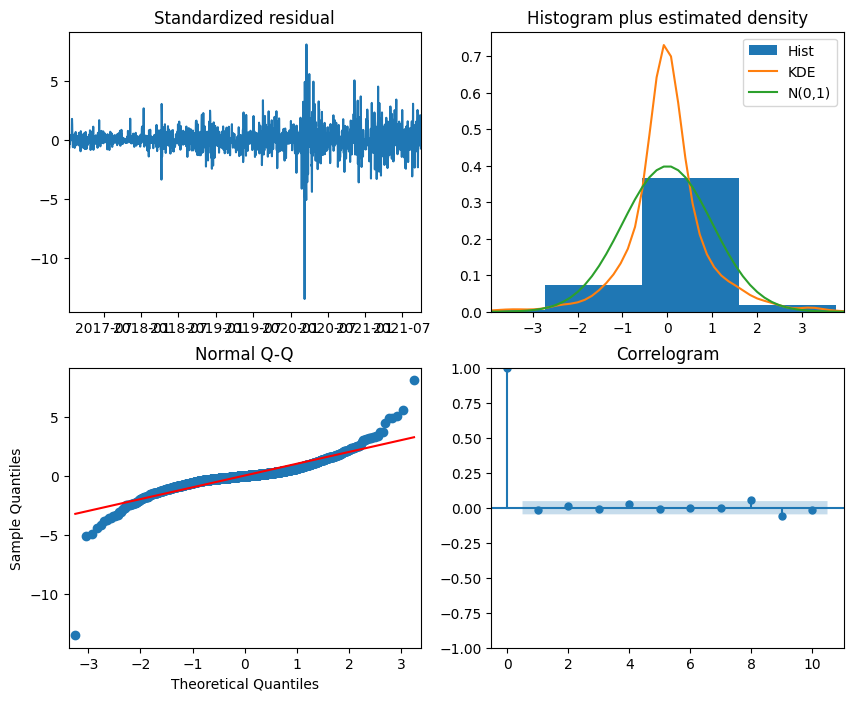

In [16]:
AUTO_ARIMA.plot_diagnostics(figsize=(10,8));

1. Standardized Residual (Стандартизованные остатки):

 * График показывает стандартизованные остатки модели во времени.
 * Остатки (разница между наблюдаемыми и предсказанными значениями) нормированы, чтобы увидеть, насколько они отклоняются от нуля.
 * Из графика видно, что остатки демонстрируют случайные колебания, однако есть несколько выбросов, которые выходят за пределы нормального диапазона. Это может указывать на наличие экстремальных значений или аномальных периодов.

2. Histogram plus Estimated Density (Гистограмма с оцененной плотностью):

 * Этот график сравнивает гистограмму остатков с оцененной плотностью распределения (KDE) и теоретическим нормальным распределением .
 * Гистограмма показывает распределение остатков, которое не полностью совпадает с нормальным распределением, так как плотность оценена не совсем как нормальная.
 * Пик гистограммы находится около нуля, но хвосты не так хорошо соответствуют нормальному распределению, что может указывать на наличие некоторых отклонений от нормальности.

3. Normal Q-Q Plot (Q-Q график):

 * Этот график сравнивает квантили теоретического нормального распределения с квантилями распределения остатков.
 * В идеале, точки должны располагаться вдоль прямой, что указывает на нормальное распределение остатков.
 * На графике видим, что большинство точек лежат близко к прямой, однако в хвостах есть отклонения, что может свидетельствовать о не нормальном распределении остатков.

4. Correlogram (Коррелограмма):

 * Коррелограмма показывает автокорреляцию остатков на различных лагах. Это помогает понять, есть ли в данных временных рядов зависимости, которые модель не уловила.
 * На графике видно, что автокорреляция на всех лагах практически равна нулю, что указывает на независимость остатков и отсутствие значимой автокорреляции. Это хороший знак, так как означает, что модель вероятно хорошо подогнана, и остатки не содержат остаточных зависимостей.

### **Выводы:**

 1. Остатки модели случайны, что является хорошим знаком, так как это предполагает, что модель адекватно описывает данные.
 2. Нормальность остатков не совсем соблюдается, что может свидетельствовать о присутствии выбросов или аномальных данных, которые не были учтены моделью.
 3. Отсутствие автокорреляции в остатках подтверждает, что модель не оставила незамеченные зависимости в данных.

Это означает, что модель в целом хороша, но для улучшения могут потребоваться дополнительные шаги для учета выбросов или для более точного описания распределения остатков.

Получены параметры для SARIMA-модели: ARIMA(0,1,0)(10,1,0)

* $p = 0$,
* $d = 1$, 
* $q = 0$,
* $P = 10$,
* $D = 1$,
* $q = 0$.

AIC	19298.493

## 3.3 Модель SARIMA

Построим SARIMA-модель на параметрах полученных ранее:

* $p = 1$,
* $d = 1$, 
* $q = 0$.

И сравним метрики AIC от модели SARIMA на гиперпараметрах и вручную.

In [17]:
# создаём объект класса ARIMA, обучаем модель
model_ARIMA = model.ARIMA(
    train_df, 
    enforce_stationarity=False, 
    order=(1, 1, 0), 
    seasonal_order=(1, 1, 0, 5)
)
model_ARIMA_fit = model_ARIMA.fit();

# выводим результат
model_ARIMA_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                    
=======================================================================================
Dep. Variable:                         LKOH.ME   No. Observations:                 1732
Model:             ARIMA(1, 1, 0)x(1, 1, 0, 5)   Log Likelihood               -9888.708
Date:                         Thu, 20 Mar 2025   AIC                          19783.417
Time:                                 16:02:42   BIC                          19799.767
Sample:                             01-03-2017   HQIC                         19789.466
                                  - 09-30-2021                                         
Covariance Type:                           opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0265      0.011     -2.388      0.017      -0.048      -0.005
ar.S.L5       -0.4990      0.009    -57.915      0.000      -0.516      -0.482
sigma2      5771.1274     66.745     86.465      0.000    5640.309    5901.946
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             18836.58
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               9.11   Skew:                            -0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Оценим визуально модель SARIMA построенную на параметрах подобранных вручную:

* Значения квантилей всё также располагаются вдоль прямой (хотя, визуально их немного "потянуло" незначительно в стороны от прямой),
* Остатки без изменений, если сравнивать с графиком модели на гиперпараметрах,
* Коррелограмма без изменений.

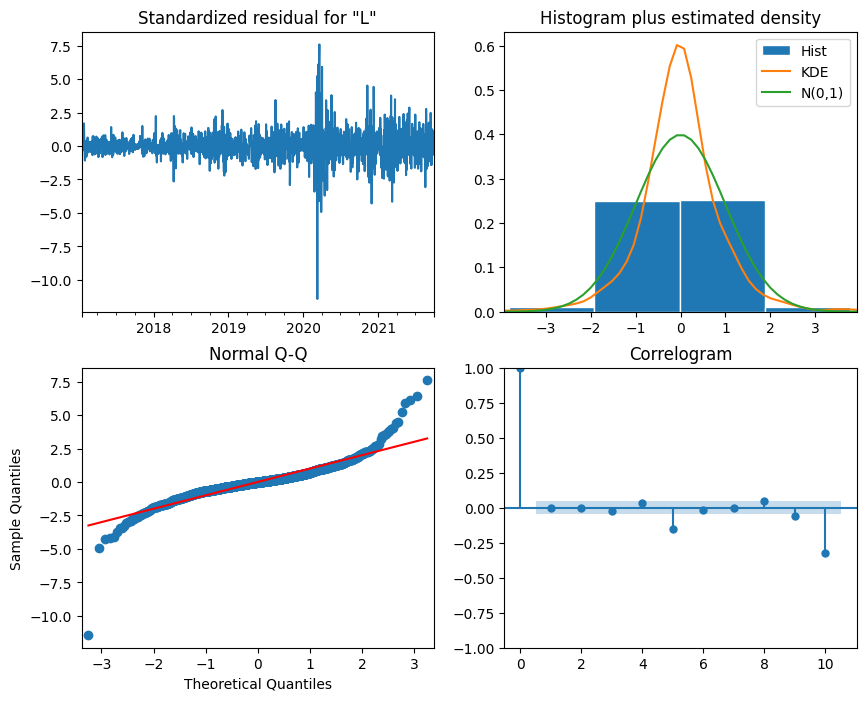

In [18]:
model_ARIMA_fit.plot_diagnostics(figsize=(10, 8));

Основываясь на ранее полученных данных, оставляем модель на параметрах вручную, от модели на гиперпараметрах отказываемся, в связи с:

* Затраченное время в 2 минуты того не стоит, т.к. метрика AIC хуже,
* Визуально отличия минимальные, можно сказать, укладывается в погрешность.

Построим предсказание модели ARIMA(1, 1, 0)x(1, 1, 0, 5):

In [19]:
# создаём отдельный датафрейм с индексами первоначального 
pred_model_ARIMA_fit = pd.DataFrame(index=data.index)

# вычисляем предсказание для тестовой выборки в новый признак 'model_preds'
pred_model_ARIMA_fit['model_preds'] = model_ARIMA_fit.predict(
    start=test_df.index[0], 
    end=test_df.index[-1]
)

# переносим истинные значения в датафрейм предсказания
pred_model_ARIMA_fit[data.columns[0]] = data[data.columns[0]]

# формируем доверительный интервал в 95%
forecast_mod = model_ARIMA_fit.get_forecast(len(test_df.index))
forecast_df_mod = forecast_mod.conf_int(alpha = 0.05)   # Confidence level of 95%

# добавляем доверительный интервал для 3 последних значений
pred_model_ARIMA_fit.at[test_df.index, 'model_preds_lower'] = forecast_df_mod[forecast_df_mod.columns[0]]
pred_model_ARIMA_fit.at[test_df.index, 'model_preds_upper'] = forecast_df_mod[forecast_df_mod.columns[1]]
pred_model_ARIMA_fit.tail()

,model_preds,LKOH.ME,model_preds_lower,model_preds_upper
2021-12-26,9133.529124,6318.0,-603.965655,18871.023904
2021-12-27,9192.019783,6370.0,-705.749807,19089.789372
2021-12-28,9189.149437,6479.0,-866.340336,19244.639210
2021-12-29,9143.894618,6488.5,-1066.879421,19354.668657
2021-12-30,9156.993127,6571.0,-1224.201972,19538.188226


Визуализируем предсказание

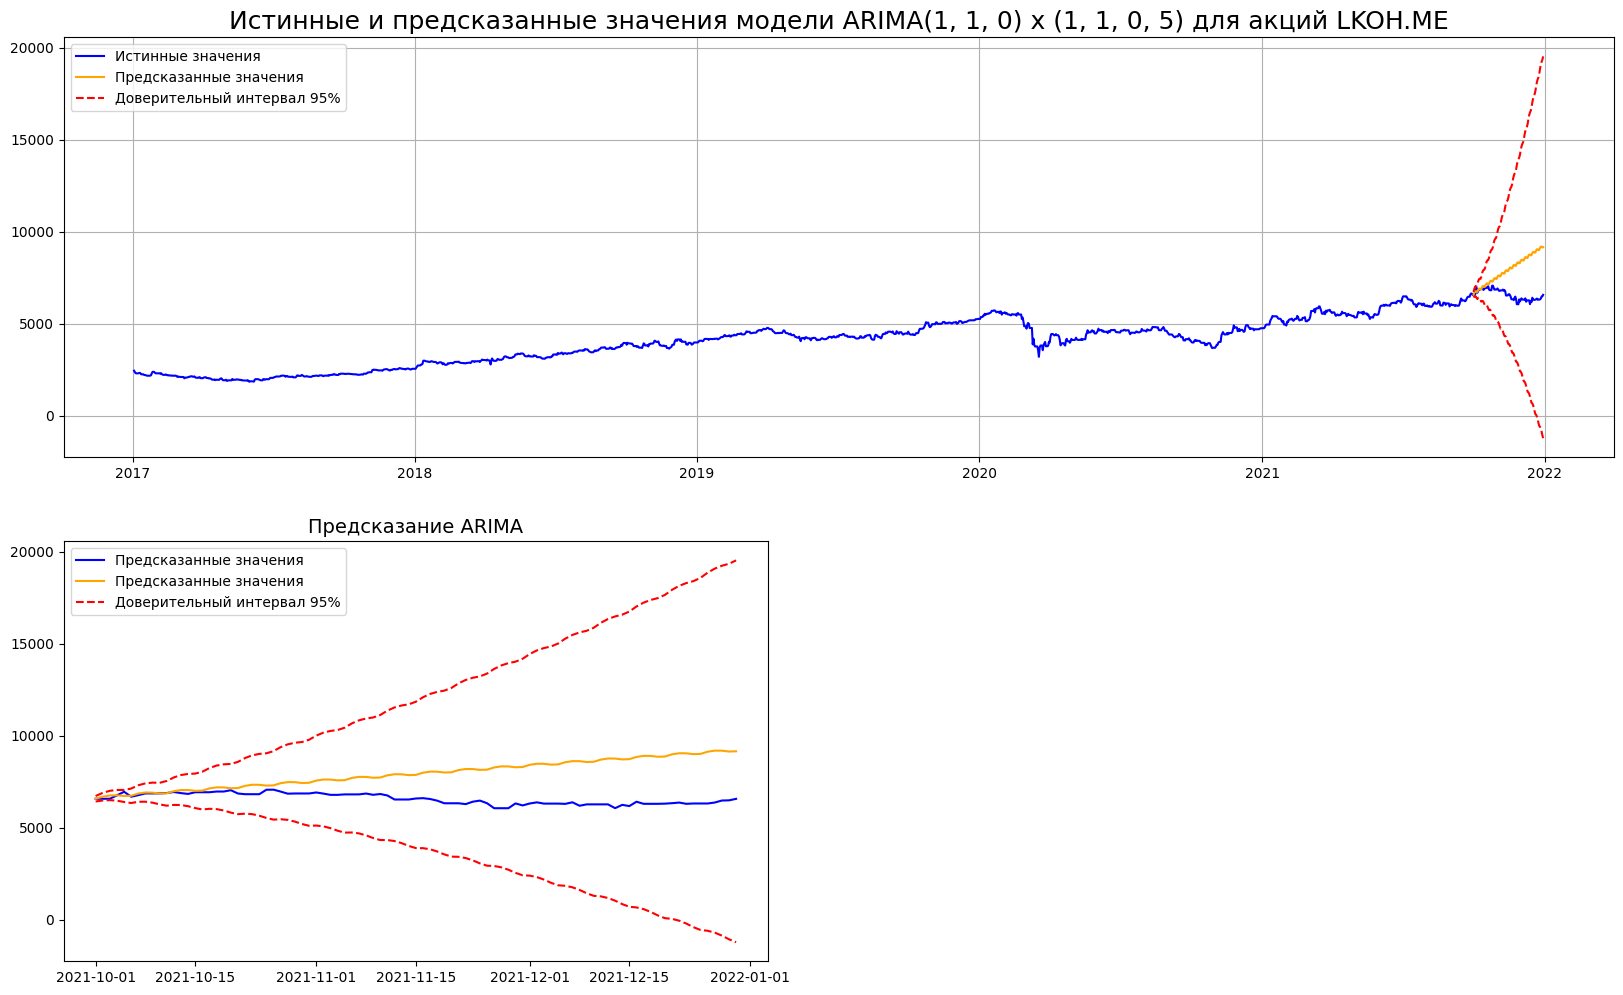

In [23]:
get_plot_time_series_predicted(
    pred_model_ARIMA_fit, test_df, 
    f"Истинные и предсказанные значения модели ARIMA" \
        f"{(model_ARIMA_fit.specification['order'])} x {(model_ARIMA_fit.specification['seasonal_order'])} " \
        f"для акций {pred_model_ARIMA_fit.columns[1]}", 
    'Предсказание ARIMA'
)

Оценим модель

In [32]:
# метрики ARIMA
get_metrics(test_df, pred_model_ARIMA_fit['model_preds'][len(train_df):])

MAPE: 21.38 %
MSE: 2.82898e+06 $^2
RMSE: 1.68196e+03 $
MAPE: 21.38 %
MSE: 2.83e+06 $^2
RMSE: 1.68e+03 $


### **Выводы:**

Оптимальные гиперпараметры, найденные алгоритмом перебора сетки значений имеют далеко неидеальную метрику AIC. Построенная навскидку модель с параметрами вручную имеет более сильную метрику AIC - 19783.417

Полученные параметры для SARIMA-модели: ARIMA(1, 1, 0)x(1, 1, 0, 5)

* $p = 1$,
* $d = 1$, 
* $q = 0$,
* $P = 1$,
* $D = 1$,
* $q = 0$.

Модель ARIMA(1, 1, 0)x(1, 1, 0, 5) с т.з. оценок метрик имеет пока лучшие метрики, они **сильно улучшены по сравнению с baseline-решением** почти в 4 раза по MAPE, более, чем в 2 раза по MSE и более, чем в 3 раза по RMSE.

---

## 3.4 Модель PROPHET

Преобразуем датасет для работы с Prophet

In [33]:
# требуется наличие признаков ds и y
data_prophet = data.reset_index().rename(columns={'index':'ds', data.columns[0]:'y'})
data_prophet['ds'] = data_prophet['ds'].astype({'ds':'object'})
data_prophet['ds'] = data_prophet['ds'].apply(lambda x: x.strftime("%Y-%m-%d"))

Разобъём выборку в соответствии с установленной пропорцией тренировочной и тестовой выборок

In [34]:
# разбиение выборки
train_prophet, test_prophet = split_data(data_prophet, SPLIT_SIZE)

# выводим результат
print(f'Размерность тренировочной выборки: {train_prophet.shape}')
print(f'Размерность тестовой выборки: {test_prophet.shape}')

Размерность тренировочной выборки: (1732, 2)
Размерность тестовой выборки: (91, 2)


In [35]:
# выводим результат
test_prophet

,ds,y
1732,2021-10-01,6574.676270
1733,2021-10-02,6574.676270
1734,2021-10-03,6574.676270
1735,2021-10-04,6760.166016
1736,2021-10-05,6954.668945
...,...,...
1818,2021-12-26,6318.000000
1819,2021-12-27,6370.000000
1820,2021-12-28,6479.000000
1821,2021-12-29,6488.500000


Обучим модель Prophet и вычислим прогноз

In [36]:
# задаём модель и обучаем её
prophet_model = Prophet(weekly_seasonality=True)
prophet_model.fit(train_prophet)

# вычисляем предсказание на тестовой выборке
future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='D')
forecast = prophet_model.predict(future)

# формируем подвыборку тестовых предсказаний
test_forecast = forecast[-len(test_prophet):];

18:35:21 - cmdstanpy - INFO - Chain [1] start processing
18:35:22 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
# создаём отдельный датафрейм с индексами первоначального 
pred_prophet_fit = pd.DataFrame(index=data_prophet.index)

# переносим предсказание для тестовой выборки в новый признак 'model_preds'
pred_prophet_fit['model_preds'] = test_forecast['yhat']

# переносим истинные значения в датафрейм предсказания
pred_prophet_fit['Close'] = data_prophet[data_prophet.columns[1]]

# добавляем доверительный интервал для 3 последних значений
pred_prophet_fit.at[test_prophet.index, 'model_preds_lower'] = test_forecast['yhat_lower']
pred_prophet_fit.at[test_prophet.index, 'model_preds_upper'] = test_forecast['yhat_upper']

# формируем индексы как в первоначальных данных (временнЫе метки)
pred_prophet_fit.index = data.index

# выводим результат
pred_prophet_fit

,model_preds,Close,model_preds_lower,model_preds_upper
2017-01-03,NaN,2443.931641,NaN,NaN
2017-01-04,NaN,2378.646484,NaN,NaN
2017-01-05,NaN,2309.943115,NaN,NaN
2017-01-06,NaN,2300.372070,NaN,NaN
2017-01-07,NaN,2300.372070,NaN,NaN
...,...,...,...,...
2021-12-26,7004.606411,6318.000000,6700.019692,7340.949513
2021-12-27,7015.997547,6370.000000,6700.638130,7336.704564
2021-12-28,7033.206905,6479.000000,6731.683264,7344.056353
2021-12-29,7058.054553,6488.500000,6743.701576,7380.618208


Визуализируем предсказание

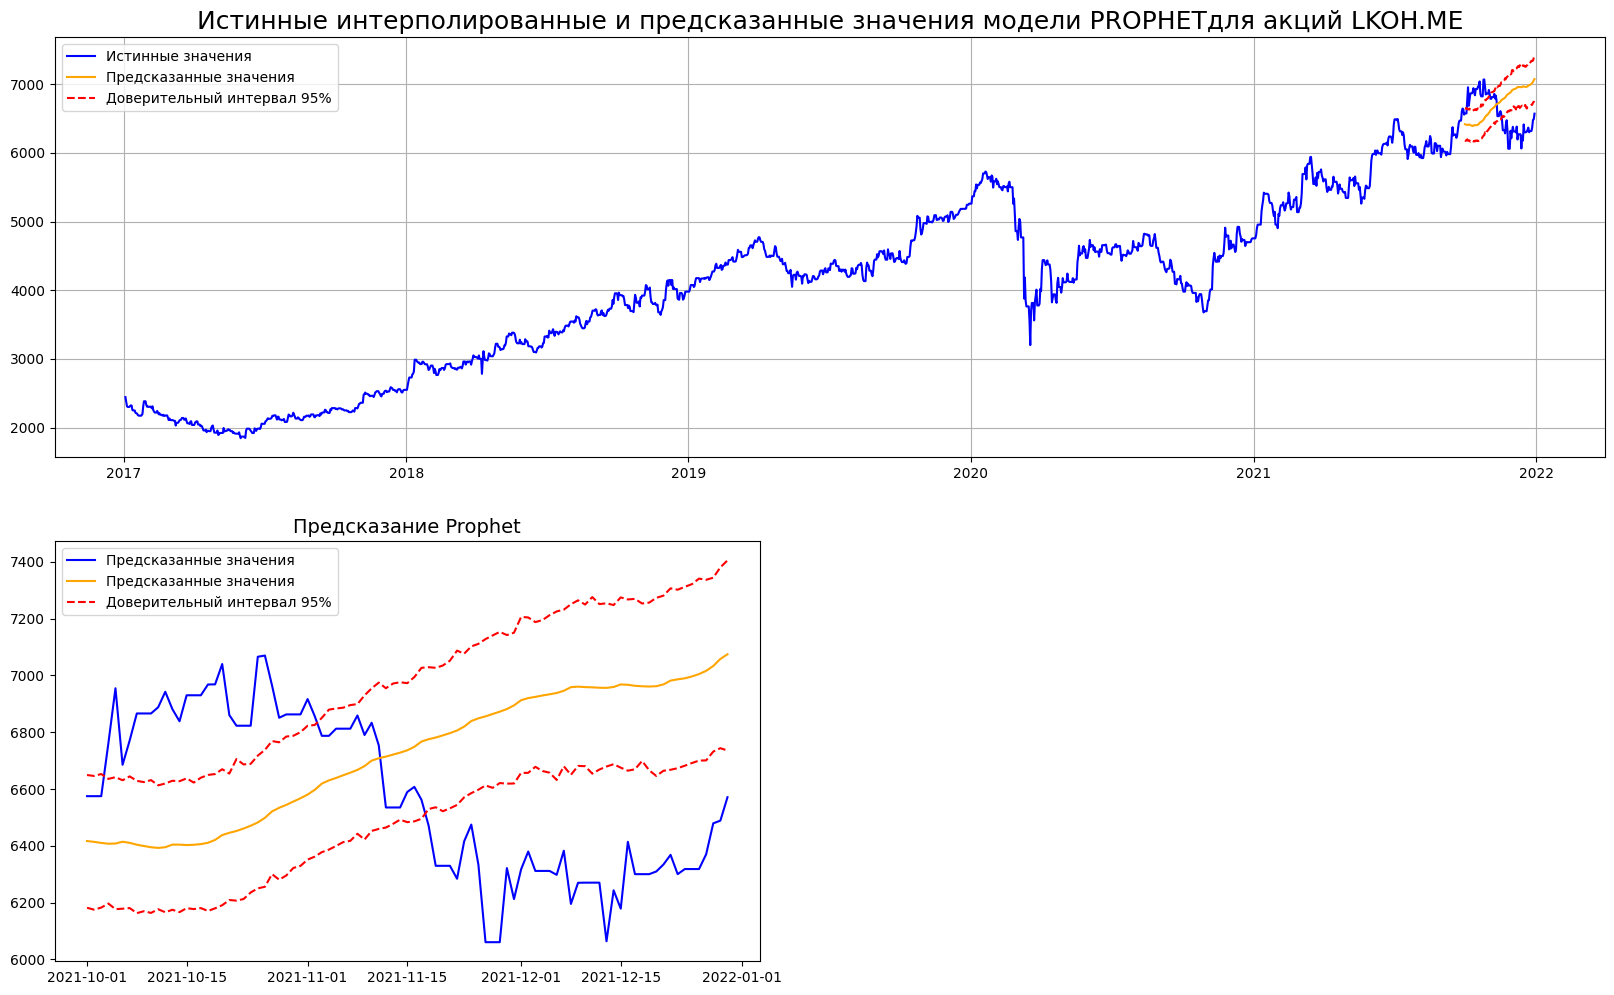

In [38]:
get_plot_time_series_predicted(
    pred_prophet_fit, test_df, 
    f"Истинные интерполированные и предсказанные значения модели PROPHET" \
        f"для акций {pred_model_ARIMA_fit.columns[1]}", 
    'Предсказание Prophet'
)

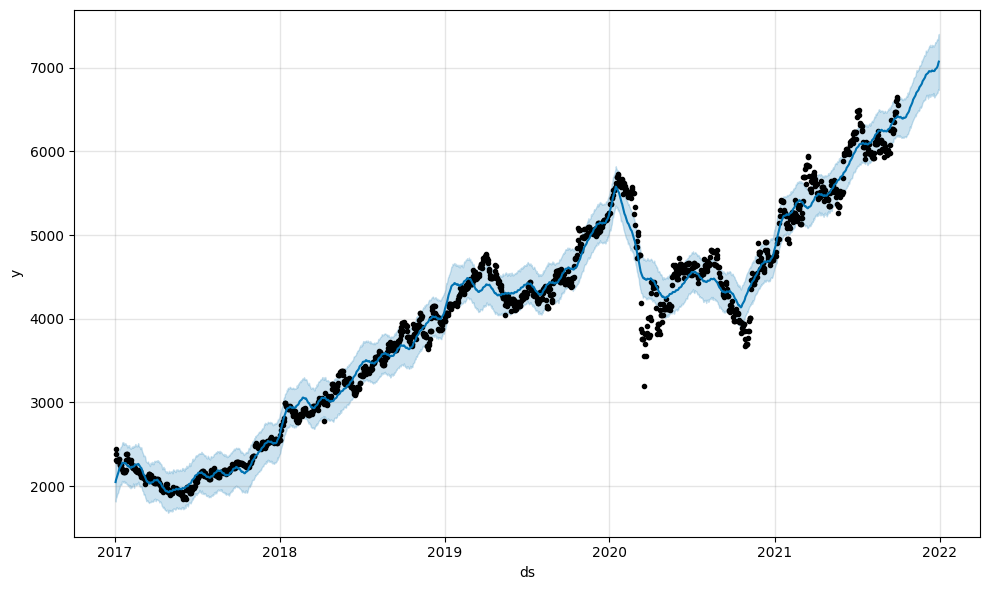

In [39]:
# визуализация прогноза
prophet_model.plot(forecast);

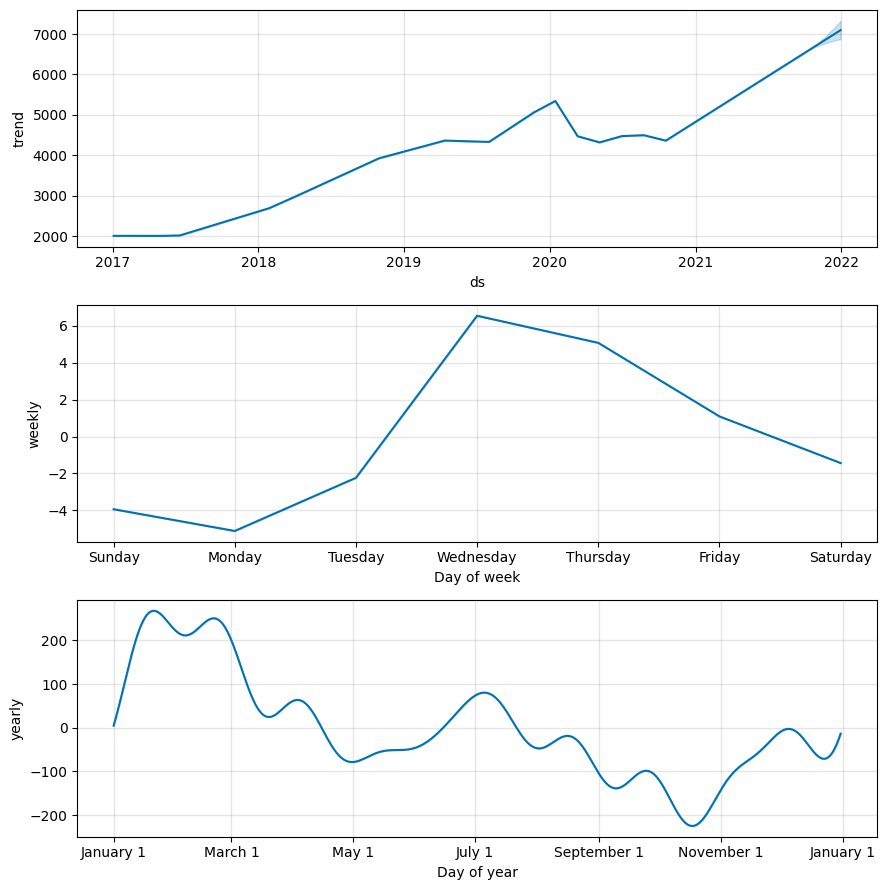

In [40]:
# визуализация трендов
prophet_model.plot_components(forecast);

Посмотрим на метрики

In [41]:
get_metrics(test_df.values, test_forecast['yhat'])

MAPE: 7.21 %
MSE: 2.60378e+05 $^2
RMSE: 5.10273e+02 $
MAPE: 7.21 %
MSE: 2.60e+05 $^2
RMSE: 5.10e+02 $


### **Выводы:**

На первый взгляд, визуально, модель неплохо подстроилась под данные, но метрики говорят об обратном - некоторый "откат" назад, даже, хуже *baseline*-решения. Видно, что предсказание модели **Prophet** не уловило тенденцию. Объяснить это можно тем, что **Prophet** лучше всего работает с временными рядами, которые имеют сильные сезонные эффекты, что является не нашим случаем.

---

## 3.5 Ансамблевая модель

Попробуем каскадную ансаблевую голосующую модель. Главная (родительская) голосующая модель будет состоять из 4 дочерних:

* *LinearRegression*,
* *AdaBoostRegressor*, 
* *RandomForestRegressor*, 
* *GradientBoostingRegressor*.

In [42]:
# формируем тренировочную и тестовую выборки
X_train = pd.DataFrame(range(data[data.columns[0]].shape[0]))[:train_df.shape[0]]
X_test = pd.DataFrame(range(data[data.columns[0]].shape[0]))[train_df.shape[0]:]
y_train = train_df[train_df.columns[0]]
y_test = test_df[test_df.columns[0]]

In [43]:
# задаём объект класса TimeSeriesSplit для сплитования time series
TSS = model_selection.TimeSeriesSplit(n_splits=CV_FOLDS, test_size=3)

# задаём объект класса LinearRegression
LR = linear_model.LinearRegression(n_jobs=CPU_ALL)

# задаём объект класса AdaBoostRegressor
ADA = ensemble.AdaBoostRegressor(random_state=RANDOM_SEED_42)

# задаём объект класса RandomForestRegressor
RFR = ensemble.RandomForestRegressor(
    n_jobs=CPU_ALL, 
    random_state=RANDOM_SEED_42,
    warm_start=True
)

# задаём объект класса GradientBoostingRegressor
GBR = ensemble.GradientBoostingRegressor(
    random_state=RANDOM_SEED_42,
    warm_start=True
)

# задаём голосующий ансамбль VotingRegressor
VR = ensemble.VotingRegressor(
    estimators=[('lr', LR), ('ada', ADA), ('rf', RFR), ('gbr', GBR)], 
    n_jobs=CPU_ALL
)

# обучаем модель VotingRegressor и предсказание на тестовой выборке
VR.fit(X_train, y_train)

score = model_selection.cross_val_score(
    VR,
    X_train, y_train,
    scoring='neg_mean_squared_error',
    cv=TSS, 
    n_jobs=CPU_ALL
).mean()
print(f'MSE на кросс-валидации: {-score:.{TOL}f}')

# вычисляем предсказание
pred_VR_test = VR.predict(X_test)

VotingRegressor(estimators=[('lr', LinearRegression(n_jobs=-1)),
                            ('ada', AdaBoostRegressor(random_state=42)),
                            ('rf',
                             RandomForestRegressor(n_jobs=-1, random_state=42,
                                                   warm_start=True)),
                            ('gbr',
                             GradientBoostingRegressor(random_state=42,
                                                       warm_start=True))],
                n_jobs=-1)

MSE на кросс-валидации: 56354.79691


Оцениваем метрики

In [44]:
get_metrics(test_df, pred_VR_test)

MAPE: 4.36 %
MSE: 1.36607e+05 $^2
RMSE: 3.69603e+02 $
MAPE: 4.36 %
MSE: 1.37e+05 $^2
RMSE: 3.70e+02 $


### **Выводы:**

Каскад из 4 моделей хорош уступает SARIMA.

---

## 3.6 Модель CatBoostRegressor

In [48]:
# создаём объект класса CatBoostRegressor, обучаем модель
CBR = cb.CatBoostRegressor(
    random_state=RANDOM_SEED_42, 
    task_type="CPU",        # используем GPU
    devices='0:1',          # используем все видеокарты
    verbose=100,            # вывести лог каждые 100 итераций
)

In [49]:
# задаём объект класса GridSearchCV с кросс-валидацией TimeSeriesSplit, обучаем модель
GSCV_CBR = model_selection.GridSearchCV(
    estimator=CBR, 
    param_grid={'iterations': [999]}, 
    scoring='neg_mean_squared_error', 
    n_jobs=CPU_ALL, 
    cv=TSS, 
    verbose=1
)

# обучаем модель, ищем оптимальный гиперпараметр
GSCV_CBR.fit(X_train, y_train)

# вычисляем предсказание GridSearchCV с CatBoostRegressor на тестовой выборке
pred_GSCV_CBR_test = GSCV_CBR.predict(X_test)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Learning rate set to 0.044691
0:	learn: 1181.6086666	total: 129ms	remaining: 2m 8s
100:	learn: 148.9573573	total: 235ms	remaining: 2.09s
200:	learn: 105.8797550	total: 335ms	remaining: 1.33s
300:	learn: 89.9366373	total: 440ms	remaining: 1.02s
400:	learn: 81.5716627	total: 550ms	remaining: 820ms
500:	learn: 76.3947704	total: 657ms	remaining: 653ms
600:	learn: 73.0673255	total: 795ms	remaining: 526ms
700:	learn: 70.7146998	total: 907ms	remaining: 385ms
800:	learn: 69.3073839	total: 1.01s	remaining: 250ms
900:	learn: 68.2002957	total: 1.12s	remaining: 121ms
998:	learn: 67.3561003	total: 1.22s	remaining: 0us


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=3),
             estimator=<catboost.core.CatBoostRegressor object at 0x000001A9F7613440>,
             n_jobs=-1, param_grid={'iterations': [999]},
             scoring='neg_mean_squared_error', verbose=1)

Оценим модель

In [50]:
get_metrics(test_df, pred_GSCV_CBR_test)

MAPE: 3.87 %
MSE: 8.10813e+04 $^2
RMSE: 2.84748e+02 $
MAPE: 3.87 %
MSE: 8.11e+04 $^2
RMSE: 2.85e+02 $


### **Выводы:**

Несмотря на всю мощь, метрики говорят о хороших показателях. Метрики чуть-чуть уступают каскадному решению VotingRegressor, можно сказать, идут вровень, лучше модели **Prophet**. **CatBoostRegressor** не смогла уловить сезонные эффекты.

---

# 4. Выводы



* Только модель SARIMA показала результаты, соответствующие ожиданиям - наилучшие.

* Автоматический подбор гиперпараметров показал себя не очень удачно, на всех котировках просадка по метрике - AIC.

* Модель Prophet не смогла показать хороший результат ни на одной котировке, тут может быть как неучтённая моделью сезонность, так и возможные пробелы в исследовании.

* Каскадный ансамбль из 4 моделей, в целом, показал себя лучше CatBoost.

---

# 5. Вывод в продакшн

## 5.1 Подготовка модели к продакшену

In [ ]:
# сериализуем pipeline и записываем результат в файл
with open('../microservice/app/model/arima.pkl', 'wb') as output:
    pickle.dump(model_ARIMA_fit, output)

## 5.2 Dockerfile

Структура каталогов микросервиса:

```py
PROJECT_final
    └─microservice
        ├─app
        |   ├─model
        |   |   └─arima.pkl
        |   └─server.py
        ├─project_final_venv\
        ├─Dockerfile
        ├─requirements.txt
        └─uwsgi.ini
```

Содержание `Dockerfile`:

```py
FROM tiangolo/uwsgi-nginx-flask:python3.10
COPY ./app/ ./
COPY ./requirements.txt ./
COPY ./uwsgi.ini ./
RUN pip install --no-cache-dir -r requirements.txt
CMD [ "python", "./server.py" ]
```

## 5.3 Сборка и запуск сервиса

Для сборки контейнера пишем в консоли

In [ ]:
# docker build -t git:latest ..

Для запуска контейнера как сервис пишем в консоли

In [ ]:
# docker run -it -d --rm -p 5000:5000 --name server_container server_image

## 5.4 Получение предсказания

 http://127.0.0.1:5000/predict?date=2025-03-20